# **라이브러리 설치**

In [39]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway
from matplotlib import pyplot as plt

# **구글 드라이브 연동**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **데이터 전처리**

In [18]:
df = pd.read_csv('/content/drive/MyDrive/vgames2.csv')
df.head()

,Unnamed: 0,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,1,Candace Kane's Candy Factory,DS,2008.0,Action,Destineer,0.04,0,0,0
1,2,The Munchables,Wii,2009.0,Action,Namco Bandai Games,0.17,0,0,0.01
2,3,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010.0,Adventure,Alchemist,0,0,0.02,0
3,4,Deal or No Deal: Special Edition,DS,2010.0,Misc,Zoo Games,0.04,0,0,0
4,5,Ben 10 Ultimate Alien: Cosmic Destruction,PS3,2010.0,Platform,D3Publisher,0.12,0.09,0,0.04


In [19]:
df = df.drop(columns=['Unnamed: 0'], axis=1)
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,Candace Kane's Candy Factory,DS,2008.0,Action,Destineer,0.04,0,0,0
1,The Munchables,Wii,2009.0,Action,Namco Bandai Games,0.17,0,0,0.01
2,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010.0,Adventure,Alchemist,0,0,0.02,0
3,Deal or No Deal: Special Edition,DS,2010.0,Misc,Zoo Games,0.04,0,0,0
4,Ben 10 Ultimate Alien: Cosmic Destruction,PS3,2010.0,Platform,D3Publisher,0.12,0.09,0,0.04


In [20]:
pd.DataFrame(df.isnull().sum(), columns=["결측치 개수"]) #결측치 확인

,결측치 개수
Name,0
Platform,0
Year,271
Genre,50
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


**연도, 장르, 게임 출판회사는 결측값 replace가 불가능하다고 판단되어 drop 하겠습니다.**

In [22]:
df = df.dropna(axis = 0)
df

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,Candace Kane's Candy Factory,DS,2008.0,Action,Destineer,0.04,0,0,0
1,The Munchables,Wii,2009.0,Action,Namco Bandai Games,0.17,0,0,0.01
2,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010.0,Adventure,Alchemist,0,0,0.02,0
3,Deal or No Deal: Special Edition,DS,2010.0,Misc,Zoo Games,0.04,0,0,0
4,Ben 10 Ultimate Alien: Cosmic Destruction,PS3,2010.0,Platform,D3Publisher,0.12,0.09,0,0.04
...,...,...,...,...,...,...,...,...,...
16593,Ice Age 2: The Meltdown,GC,2006.0,Platform,Vivendi Games,0.15,0.04,0,0.01
16594,Rainbow Islands: Revolution,PSP,2005.0,Action,Rising Star Games,0.01,0,0,0
16595,NBA 2K16,PS3,2015.0,Sports,Take-Two Interactive,0.44,0.19,0.03,0.13
16596,Toukiden: The Age of Demons,PSV,2013.0,Action,Tecmo Koei,0.05,0.05,0.25,0.03


In [23]:
df['Platform'].unique()

array(['DS', 'Wii', 'PSP', 'PS3', 'PC', 'PS', 'GBA', 'PS4', 'PS2', 'XB',
       'X360', 'GC', '3DS', '2600', 'SAT', 'GB', 'NES', 'DC', 'N64',
       'XOne', 'SNES', 'WiiU', 'PSV', 'GEN', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [24]:
df['Year'].unique()

array([2.008e+03, 2.009e+03, 2.010e+03, 2.005e+03, 2.011e+03, 2.007e+03,
       2.001e+03, 2.003e+03, 2.006e+03, 2.014e+03, 2.015e+03, 2.002e+03,
       1.997e+03, 2.013e+03, 1.996e+03, 2.004e+03, 2.000e+03, 1.984e+03,
       1.998e+03, 2.016e+03, 1.985e+03, 1.999e+03, 9.000e+00, 9.700e+01,
       1.995e+03, 1.993e+03, 2.012e+03, 1.987e+03, 1.982e+03, 1.100e+01,
       1.994e+03, 1.990e+03, 1.500e+01, 1.992e+03, 1.991e+03, 1.983e+03,
       1.988e+03, 1.981e+03, 3.000e+00, 1.989e+03, 9.600e+01, 6.000e+00,
       8.000e+00, 1.986e+03, 1.000e+00, 5.000e+00, 4.000e+00, 1.000e+01,
       9.800e+01, 7.000e+00, 1.600e+01, 8.600e+01, 1.400e+01, 9.500e+01,
       2.017e+03, 1.980e+03, 2.020e+03, 2.000e+00, 1.300e+01, 0.000e+00,
       1.200e+01, 9.400e+01])

In [26]:
df.iloc[72]

Name           Age of Empires III: Complete Collection
Platform                                            PC
Year                                               9.0
Genre                                         Strategy
Publisher                       Microsoft Game Studios
NA_Sales                                          0.01
EU_Sales                                          0.12
JP_Sales                                             0
Other_Sales                                       0.03
Name: 74, dtype: object

**Year 값이 통일된 단위를 사용하지 않는 것 같습니다.**

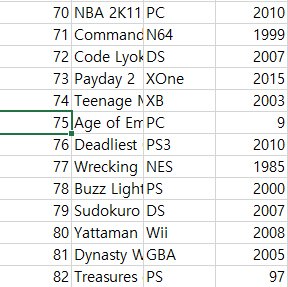

**Sales 값 또한 통일된 단위를 사용하지 않는 것 같습니다.**

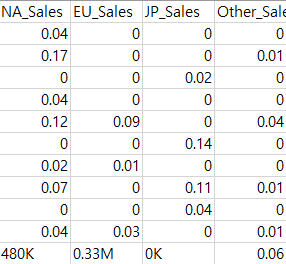

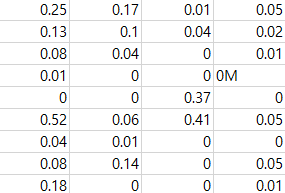

**Year, Sales column 처리 작업 진행**

In [27]:
def value_to_float(x): # sales 단위 통일
    if type(x) == float or type(x) == int:
        return x
    if 'K' in x:
        if len(x) > 1:
            return float(x.replace('K', '')) * 1000
        return 1000.0 
    if 'M' in x:
        if len(x) > 1:
            return float(x.replace('M', '')) * 1000000
        return 1000000.0
    if type(x) == str:
        return x    

df['NA_Sales'] = df['NA_Sales'].apply(value_to_float)
df['NA_Sales'] = pd.to_numeric(df['NA_Sales'], errors='coerce')
df['EU_Sales'] = df['EU_Sales'].apply(value_to_float)
df['EU_Sales'] = pd.to_numeric(df['EU_Sales'], errors='coerce')
df['JP_Sales'] = df['JP_Sales'].apply(value_to_float)
df['JP_Sales'] = pd.to_numeric(df['JP_Sales'], errors='coerce')
df['Other_Sales'] = df['Other_Sales'].apply(value_to_float)
df['Other_Sales'] = pd.to_numeric(df['Other_Sales'], errors='coerce')  #K와 M 같은 단위 M로 통일시키는 과정에서 문자 단위 제거

def value_to_float2(x):
    if x > 1000:
        return x / 1000000
    else:
      return x

df['NA_Sales'] = df['NA_Sales'].apply(value_to_float2)
df['EU_Sales'] = df['EU_Sales'].apply(value_to_float2)
df['JP_Sales'] = df['JP_Sales'].apply(value_to_float2)
df['Other_Sales'] = df['Other_Sales'].apply(value_to_float2) #지역별 출고량 단위 통일과정

In [28]:
df.head(20)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,Candace Kane's Candy Factory,DS,2008.0,Action,Destineer,0.04,0.00,0.00,0.00
1,The Munchables,Wii,2009.0,Action,Namco Bandai Games,0.17,0.00,0.00,0.01
2,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010.0,Adventure,Alchemist,0.00,0.00,0.02,0.00
3,Deal or No Deal: Special Edition,DS,2010.0,Misc,Zoo Games,0.04,0.00,0.00,0.00
4,Ben 10 Ultimate Alien: Cosmic Destruction,PS3,2010.0,Platform,D3Publisher,0.12,0.09,0.00,0.04
5,Power Pro Kun Pocket 8,DS,2005.0,Sports,Konami Digital Entertainment,0.00,0.00,0.14,0.00
6,JASF: Jane's Advanced Strike Fighters,PC,2011.0,Simulation,Deep Silver,0.02,0.01,0.00,0.00
7,Samurai Warriors: State of War,PSP,2005.0,Action,Tecmo Koei,0.07,0.00,0.11,0.01
8,Imabikisou,PS3,2007.0,Adventure,Sega,0.00,0.00,0.04,0.00
9,The Penguins of Madagascar: Dr. Blowhole Retur...,PS3,2011.0,Action,THQ,0.04,0.03,0.00,0.01


In [32]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

year = [] # 업데이트된 list를 append 하기위한 list 생성

for i in df['Year']:
    if i < 17:
      i = i + 2000
      year.append(i)
    elif i > 17 and i < 1900:
      i = i + 1900
      year.append(i)
    else:
      i = i
      year.append(i)

df['Year'] = year
df['Year'] = df['Year'].astype(int)

print(df.loc[45]) #데이터 확인

Name           Resident Evil: Revelations 2
Platform                                PS3
Year                                   2015
Genre                                Action
Publisher                            Capcom
NA_Sales                               0.06
EU_Sales                               0.08
JP_Sales                               0.16
Other_Sales                            0.03
Name: 45, dtype: object


**지역 전체 Total Sales가 있으면 분석에 도움이 될 것 같으므로 생성하겠습니다.**

In [34]:
df['Total_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
df.tail()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
16593,Ice Age 2: The Meltdown,GC,2006,Platform,Vivendi Games,0.15,0.04,0.00,0.01,0.20
16594,Rainbow Islands: Revolution,PSP,2005,Action,Rising Star Games,0.01,0.00,0.00,0.00,0.01
16595,NBA 2K16,PS3,2015,Sports,Take-Two Interactive,0.44,0.19,0.03,0.13,0.79
16596,Toukiden: The Age of Demons,PSV,2013,Action,Tecmo Koei,0.05,0.05,0.25,0.03,0.38
16597,The King of Fighters '95,PS,1996,Fighting,Sony Computer Entertainment,0.00,0.00,0.16,0.01,0.17


In [35]:
df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Total_Sales']].describe()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
count,16241.000000,16241.000000,16241.000000,16241.000000,16241.000000
mean,0.265195,0.147378,0.078283,0.048234,0.539091
std,0.822431,0.508340,0.309272,0.189678,1.563905
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.060000
50%,0.080000,0.020000,0.000000,0.010000,0.170000
75%,0.240000,0.110000,0.040000,0.040000,0.480000
max,41.490000,29.020000,10.220000,10.570000,82.740000


**데이터 내 column속 어떤 그룹들이 존재하는지 확인**

In [36]:
platform_unq = df['Platform'].unique() # 플랫폼 개수 :31개
print(len(platform_unq)) 
platform_unq

year_unq = df['Year'].unique() # 연도 데이터 : 1980년부터 2020년 까지 39개
print(len(year_unq))
year_unq

genre_unq = df['Genre'].unique() # 장르 데이터 : 12개
print(len(genre_unq))
genre_unq

#publisher_unq = df['Publisher'].unique() #퍼블리셔 데이터 : 575개
#print(len(publisher_unq))
#publisher_unq

31
39
12


array(['Action', 'Adventure', 'Misc', 'Platform', 'Sports', 'Simulation',
       'Racing', 'Role-Playing', 'Puzzle', 'Strategy', 'Fighting',
       'Shooter'], dtype=object)

# **지역에 따라서 선호하는 게임 장르가 다를까?**

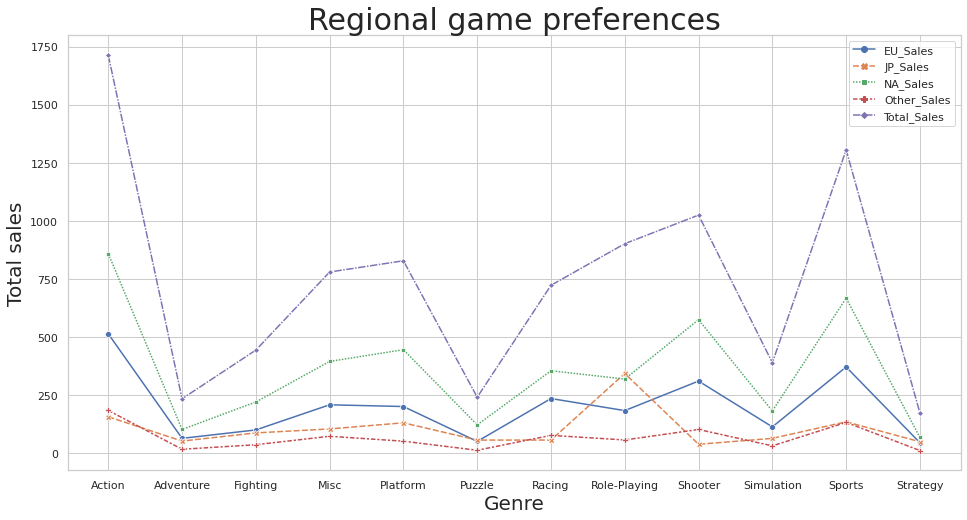

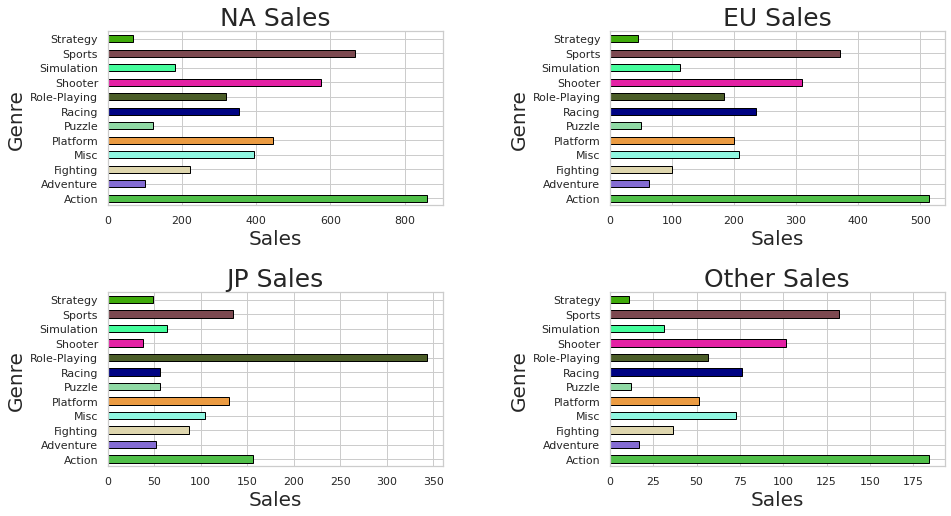

In [38]:
df_na_genre = df.groupby(by=['Genre'])['NA_Sales'].sum() #북미 내 장르별 게임 판매량 
df_na_genre = df_na_genre.reset_index() #row index를 제거하고 열 기준으로 data프레임화

df_eu_genre = df.groupby(by=['Genre'])['EU_Sales'].sum() #유럽 내 장르별 게임 판매량 
df_eu_genre = df_eu_genre.reset_index()

df_jp_genre = df.groupby(by=['Genre'])['JP_Sales'].sum() #일본 내 장르별 게임 판매량 
df_jp_genre = df_jp_genre.reset_index()

df_other_genre = df.groupby(by=['Genre'])['Other_Sales'].sum() #그 외 대륙 장르별 게임 판매량 
df_other_genre = df_other_genre.reset_index()

df_total = df.groupby(by=['Genre'])['Total_Sales'].sum() #전체 대륙 장르별 게임 판매량 
df_total = df_total.reset_index() 

df_total = df_total.combine_first(df_na_genre).combine_first(df_eu_genre).combine_first(df_jp_genre).combine_first(df_other_genre)
df_total = df_total.set_index("Genre")

sns.set(style='whitegrid')
plt.figure(figsize=(16, 8))
plt.title("Regional game preferences", fontsize=30)
plt.xlabel("Genre", fontsize=20)
plt.ylabel("Total sales", fontsize=20)

sns.lineplot(data=df_total, markers=True)


colors = ['#50BF49', '#846CD2', '#DED6AE', '#8FF6E0', '#EB9B42', '#8FD9A4', '#000383', '#4B5D28', '#E321A4', '#45FD9C', '#7C4950', '#3FAA0B', '#E02695']
fig = plt.figure()
plt.rcParams['figure.figsize'] = [15, 8]
plt.subplot(2,2,1)
df['NA_Sales'].groupby(df['Genre']).sum().plot.barh(color=colors, edgecolor='black')
plt.xlabel('Sales', fontsize =20)
plt.ylabel('Genre', fontsize =20)
plt.title('NA Sales', fontsize =25)


plt.subplot(2,2,2)
df['EU_Sales'].groupby(df['Genre']).sum().plot.barh(color=colors, edgecolor='black')
plt.xlabel('Sales', fontsize =20)
plt.ylabel('Genre', fontsize =20)
plt.title('EU Sales', fontsize =25)

plt.subplot(2,2,3)
df['JP_Sales'].groupby(df['Genre']).sum().plot.barh(color=colors, edgecolor='black')
plt.xlabel('Sales', fontsize =20)
plt.ylabel('Genre', fontsize =20)
plt.title('JP Sales', fontsize =25)

plt.subplot(2,2,4)
df['Other_Sales'].groupby(df['Genre']).sum().plot.barh(color=colors, edgecolor='black')
plt.xlabel('Sales', fontsize =20)
plt.ylabel('Genre', fontsize =20)
plt.title('Other Sales', fontsize =25)


plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

**첫번째 그래프**는 한 그래프 안에 전 지역들을 모아놔 한 눈에 비교하기 쉽게 시각화 해 보았고,

**두번째 그래프**는 각 지역별로 어떤 장르의 매출이 높은지 한 눈에 확인하기 쉽게끔 시각화 해보았다.

**일본을 제외한 북미 유럽 그 나머지 지역**들의 판매 공통점은 **Action** 게임이 제일 많이 판매 되었다는 점과, 그 다음으로 **Sports**가 뒤를 따랐다는 점이다.

그렇다면 일본의 장르별 게임 판매량을 살펴보자. **일본**에서는 **Role playing** 게임이 가장 많이 판매 되었고, 그 다음으로는 **Action** 게임이 가장 많이 판매 된 것을 확인할 수 있었다.


# **지역에 따라서 선호하는 게임 장르가 다를까?**

를 통계적으로 알아보기 위해 추가로 t-test를 진행했다.

가설은 아래와 같이 설정했다.

**귀무가설** : 실제로 지역마다 장르에 따른 판매량 평균의 차이는 없다.

**대립가설** : 실제로 지역마다 장르에 따른 판매량 평균의 차이가 존재한다.


In [40]:
#Anova test 진행

grouped = df['NA_Sales'].groupby(df['Genre'])
df1 = pd.DataFrame(grouped.sum())
np.array(df1['NA_Sales'].tolist()) #북미 장르별 판매량을 list화

grouped1 = df['EU_Sales'].groupby(df['Genre'])
df2 = pd.DataFrame(grouped1.sum())
np.array(df2['EU_Sales'].tolist())

grouped2 = df['JP_Sales'].groupby(df['Genre'])
df3 = pd.DataFrame(grouped2.sum())
np.array(df3['JP_Sales'].tolist())

grouped3 = df['Other_Sales'].groupby(df['Genre'])
df4 = pd.DataFrame(grouped3.sum())
np.array(df4['Other_Sales'].tolist()) #다른 지역들도 마찬가지로 진행

f_oneway(df1,df2,df3,df4)

F_onewayResult(statistic=array([9.05021714]), pvalue=array([8.79757491e-05]))

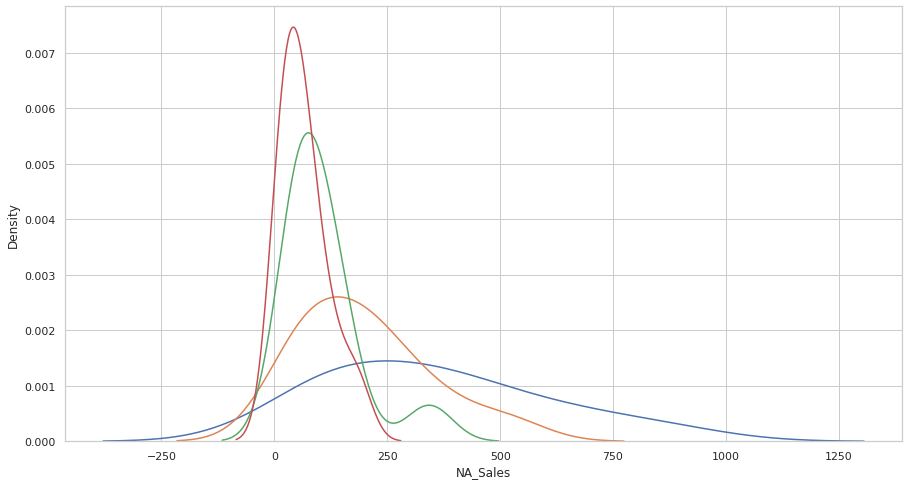

In [41]:
plt.rcParams['figure.figsize'] = [15, 8]
sns.kdeplot(df1['NA_Sales'])
sns.kdeplot(df2['EU_Sales'])
sns.kdeplot(df3['JP_Sales'])
sns.kdeplot(df4['Other_Sales'])
plt.show()

위 4개 그룹의 **커널밀도 추정 그래프**를 이용해 겹쳐서 확인해 보면, 위와 같이 **집단의 평균이 다르다는 것**을 확인할 수 있다.

또한 지역에 따라 장르별 판매량 **Anova test**의 **P-value**값이 0.05 보다 낮게 나왔기 때문에 

**대립가설인 '실제로 지역마다 장르에 따른 판매량의 차이가 존재한다.'** 를 채택.

# **연도별 게임의 트렌드가 있을까?**

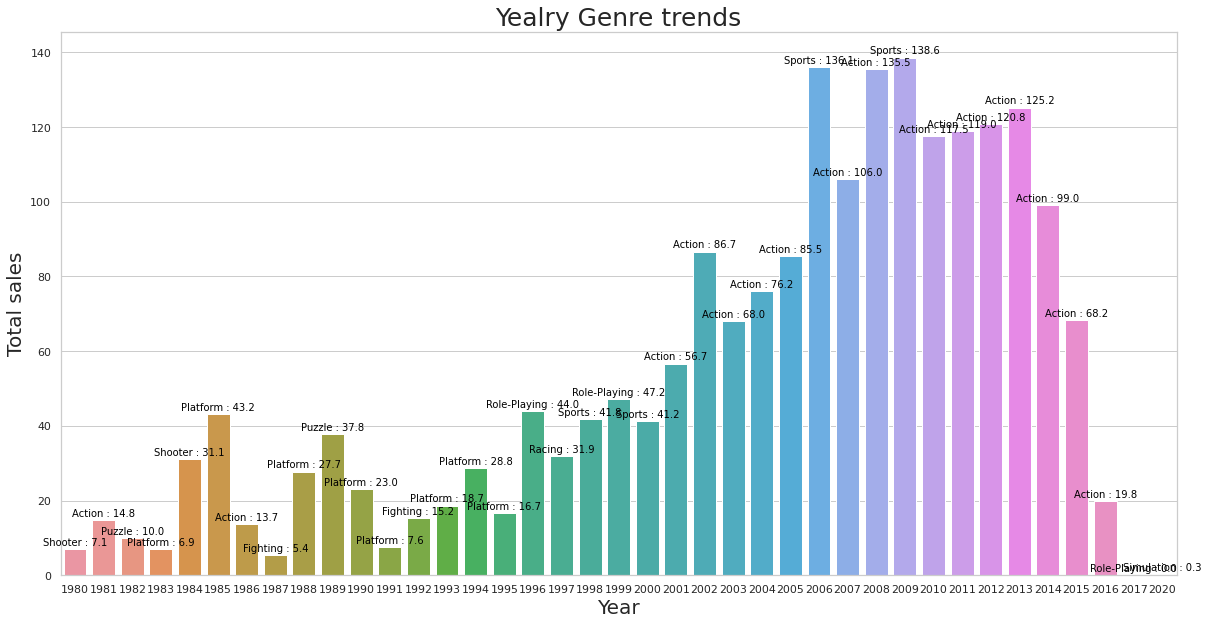

In [42]:
sales_yearly_index = df.groupby(by=['Year', 'Genre'])['Total_Sales'].sum()
sales_yearly_index = sales_yearly_index.reset_index()
sales_yearly = sales_yearly_index.groupby(by=['Year'])['Total_Sales'].transform(max) == sales_yearly_index['Total_Sales']
sales_yearly_top = sales_yearly_index[sales_yearly].reset_index()

genre = sales_yearly_top['Genre']

sns.set(style='whitegrid')
plt.figure(figsize=(20, 10))
trends = sns.barplot(x='Year', y='Total_Sales', data=sales_yearly_top)

index = 0
for value in sales_yearly_top['Total_Sales']:
    trends.text(index, value + 1, str(genre[index] + ' : ' +str(round(value, 1))), color='black', size=10, ha="center")
    index += 1

plt.title("Yealry Genre trends", fontsize=25)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total sales", fontsize=20)

plt.show()

**1980년도부터 2000년도** 까지는 트렌드를 찾기 힘들 정도로 **매년마다 새로운 장르**가 판매량이 제일 높았음을 알 수 있다.

그러나 **2000년도부터 2016년사이에 2006년과 2009년을 제외하고는 Action 게임이 확실하게 트렌드**를 유지했음을 알 수 있다.


# **그렇다면 역대 가장 많은 판매량을 기록한 게임은 무엇일까?**

In [44]:
game_sales = df.sort_values(by=['Total_Sales'], ascending=False)
top25_game = game_sales.head(25)
top25_game = top25_game[['Name','Platform','Year','Genre','Total_Sales']]
top25_game = top25_game.reset_index(drop=True)
top25_game

,Name,Platform,Year,Genre,Total_Sales
0,Wii Sports,Wii,2006,Sports,82.74
1,Super Mario Bros.,NES,1985,Platform,40.24
2,Mario Kart Wii,Wii,2008,Racing,35.83
3,Wii Sports Resort,Wii,2009,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,31.38
5,Tetris,GB,1989,Puzzle,30.26
6,New Super Mario Bros.,DS,2006,Platform,30.01
7,Wii Play,Wii,2006,Misc,29.01
8,New Super Mario Bros. Wii,Wii,2009,Platform,28.61
9,Duck Hunt,NES,1984,Shooter,28.31


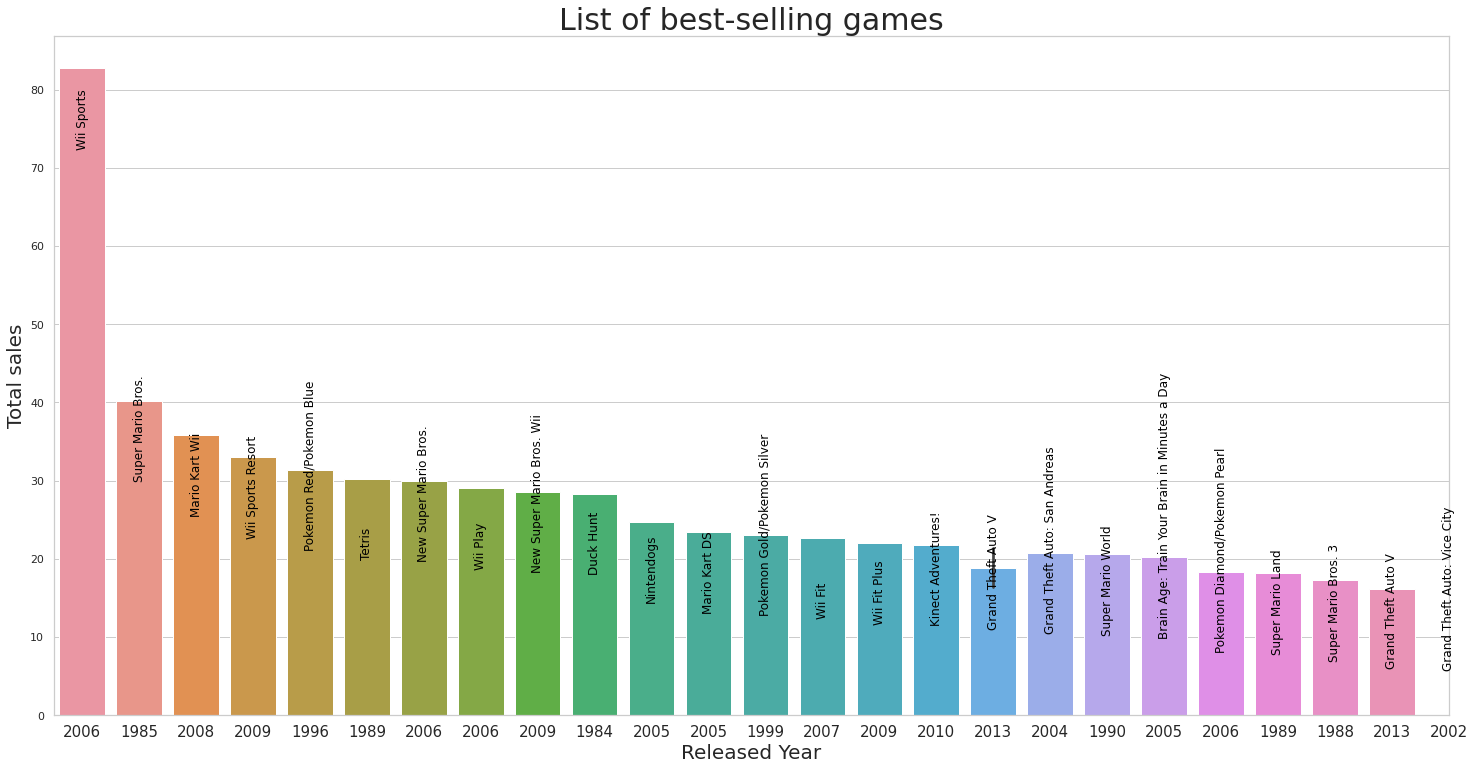

In [56]:
name = top25_game['Name']
year = top25_game['Year']
y = np.arange(0, 25)

sns.set(style='whitegrid')
plt.figure(figsize=(25, 12.5))
games = sns.barplot(x='Name', y='Total_Sales', data=top25_game)

index = 0
for value in top25_game['Total_Sales']:
    games.text(index, value - 10, name[index], color='black', size=12, rotation= 90, ha="center")
    index += 1

plt.xticks(y, top25_game['Year'], fontsize=15)
plt.title("List of best-selling games", fontsize=30)
plt.xlabel("Released Year", fontsize=20)
plt.ylabel("Total sales", fontsize=20)
plt.show()

**전 지역 역대 가장 많은 판매량**을 기록한 게임을 알아보니 **Wii Sports**가 2등인 Super Mario Bros. 보다 2배 가량 높게 **1등을 차지**했다.

앞서 알아본 트랜드에서 발견했던 **'2000년도부터 2016년까지 액션 장르게임이 대세였다.'**를 토대로한 예상과는 다르게 **역대 최고 판매량 Top 25 리스트에서는 Action 게임**이 **4개**밖에 없었다.

Text(0.5, 1.0, 'Top 10 Other Sales')

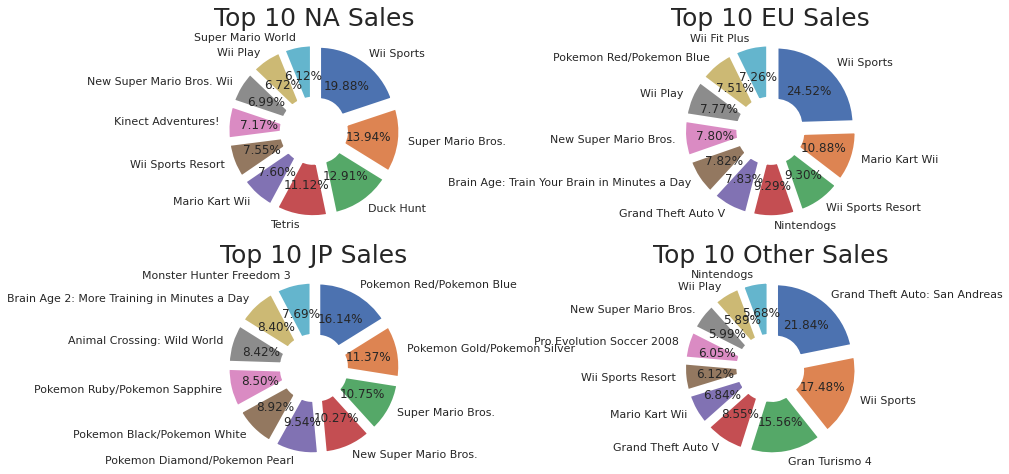

In [57]:
game_sales_na = df.sort_values(by=['NA_Sales'], ascending=False)
top10_game_na = game_sales_na.head(10)
top10_game_na = top10_game_na[['Name','Platform','Year','Genre','NA_Sales']]
top10_game_na = top10_game_na.reset_index(drop=True)
top10_game_na

plt.subplot(2,2,1)
plt.rcParams['figure.figsize'] = [20, 10]
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
custom_palette = sns.color_palette("deep", 10)
plt.pie(top10_game_na['NA_Sales'], labels = top10_game_na.Name,autopct='%.2f%%', startangle=90, explode = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1], counterclock=False, colors = custom_palette, wedgeprops=wedgeprops);
plt.title('Top 10 NA Sales' , fontsize=25)

game_sales_eu = df.sort_values(by=['EU_Sales'], ascending=False)
top10_game_eu = game_sales_eu.head(10)
top10_game_eu = top10_game_eu[['Name','Platform','Year','Genre','EU_Sales']]
top10_game_eu = top10_game_eu.reset_index(drop=True)
top10_game_eu

plt.subplot(2,2,2)
plt.rcParams['figure.figsize'] = [20, 10]
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
custom_palette = sns.color_palette("deep", 10)
plt.pie(top10_game_eu['EU_Sales'], labels = top10_game_eu.Name,autopct='%.2f%%', startangle=90, explode = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1], counterclock=False, colors = custom_palette, wedgeprops=wedgeprops);
plt.title('Top 10 EU Sales' , fontsize=25)

game_sales_jp = df.sort_values(by=['JP_Sales'], ascending=False)
top10_game_jp = game_sales_jp.head(10)
top10_game_jp = top10_game_jp[['Name','Platform','Year','Genre','JP_Sales']]
top10_game_jp = top10_game_jp.reset_index(drop=True)
top10_game_jp

plt.subplot(2,2,3)
plt.rcParams['figure.figsize'] = [20, 10]
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
custom_palette = sns.color_palette("deep", 10)
plt.pie(top10_game_jp['JP_Sales'], labels = top10_game_jp.Name,autopct='%.2f%%', startangle=90, explode = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1], counterclock=False, colors = custom_palette, wedgeprops=wedgeprops);
plt.title('Top 10 JP Sales' , fontsize=25)

game_sales_other = df.sort_values(by=['Other_Sales'], ascending=False)
top10_game_other = game_sales_other.head(10)
top10_game_other = top10_game_other[['Name','Platform','Year','Genre','Other_Sales']]
top10_game_other = top10_game_other.reset_index(drop=True)
top10_game_other

plt.subplot(2,2,4)
plt.rcParams['figure.figsize'] = [20, 10]
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
custom_palette = sns.color_palette("deep", 10)
plt.pie(top10_game_other['Other_Sales'], labels = top10_game_other.Name,autopct='%.2f%%', startangle=90, explode = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1], counterclock=False, colors = custom_palette, wedgeprops=wedgeprops);
plt.title('Top 10 Other Sales' , fontsize=25)

**대륙 별로 나눠서** **Top 10 Sales 게임**을 알아 보았다.

**북미, 유럽에서 최고 판매량**을 기록한 게임은 **Wii Sports**이며,

**일본**에서는 **Pokemon Red/Pokemon Blue**,

**기타 지역**에서는 **Grand Theft Auto: San Andreas**가 1등을 기록했다.

# **문득 궁금해졌다.**
**왜 역대 게임별 판매량으로 확인했을 때 Action게임의 비율이 게임 트랜드에 기반한 기대와 다르게 판매량이 낮아 보일까?**

그래서 다시 Top 25 게임별 판매량 그래프를 들여다 보았다.

**Top 25안에 들은 Action 게임은 4개였으며 모두 GTA** (Grand Theft Auto) 시리즈 게임인 것을 확인할 수 있었다.

21세기 이후로 액션게임이 흥행했던 것을 감안하여 **최근 10년 내의 역대 게임 판매량을 확인**하고, 실제로 트랜드에서 발견한 사실이 맞는지 알아보기로 했다.


In [58]:
current10_game_sales = df[df.Year >= 2011].sort_values('Total_Sales', ascending=False).head(10)
current10_game_sales = current10_game_sales[['Name','Platform','Year','Genre','Total_Sales']]
current10_game_sales = current10_game_sales.reset_index(drop=True)
current10_game_sales

,Name,Platform,Year,Genre,Total_Sales
0,Grand Theft Auto V,PS3,2013,Action,21.39
1,Grand Theft Auto V,X360,2013,Action,16.38
2,Call of Duty: Modern Warfare 3,X360,2011,Shooter,14.76
3,Call of Duty: Black Ops 3,PS4,2015,Shooter,14.24
4,Call of Duty: Black Ops II,PS3,2012,Shooter,14.04
5,Call of Duty: Black Ops II,X360,2012,Shooter,13.74
6,Call of Duty: Modern Warfare 3,PS3,2011,Shooter,13.47
7,Mario Kart 7,3DS,2011,Racing,12.21
8,Grand Theft Auto V,PS4,2014,Action,11.99
9,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,11.33


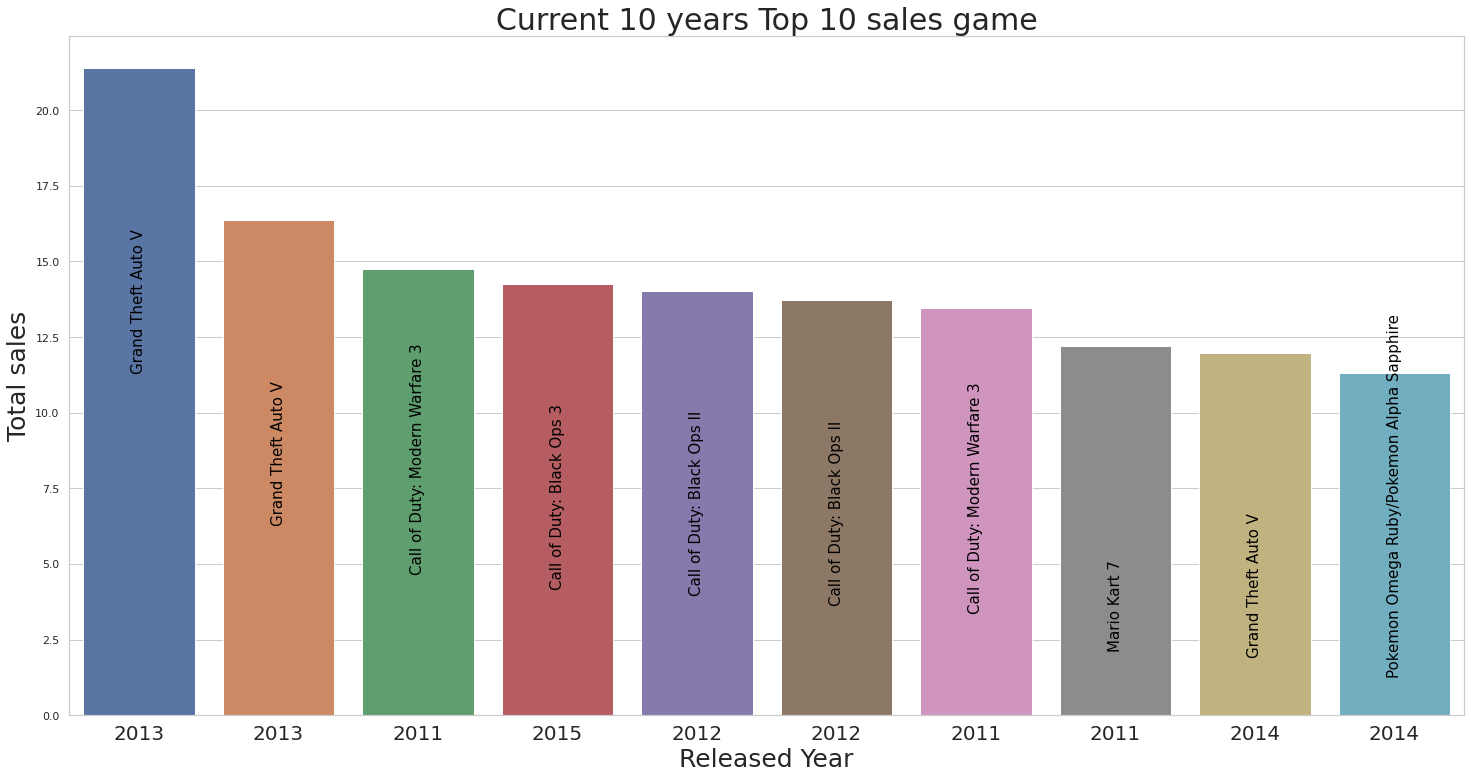

In [59]:
name1 = current10_game_sales['Name']
year1 = current10_game_sales['Year']
y = np.arange(0, 10)

sns.set(style='whitegrid')
plt.figure(figsize=(25, 12.5))
games1 = sns.barplot(x = current10_game_sales.index, y='Total_Sales', data=current10_game_sales)

index = 0
for value in current10_game_sales['Total_Sales']:
    games1.text(index, value - 10, name1[index], color='black', size=15, rotation= 90, ha="center")
    index += 1

plt.xticks(y, current10_game_sales['Year'], fontsize = 20)
plt.title("Current 10 years Top 10 sales game", fontsize = 30)
plt.xlabel("Released Year", fontsize = 25)
plt.ylabel("Total sales", fontsize = 25)
plt.show()

**실제로 GTA**의 **최근 10년 내** 게임 판매량이 **압도적으로 1등**이었다. 

또한 **최근 10년동안 Top 10 판매량**을 기록한 게임들은 **모두 시리즈물**이며, **Action, Shooter 장르**가 과반수였다.

이 데이터 내에서 시리즈 게임인 GTA는 어떠한 형태로 흩어져 있는지 알아보기로 했다.

In [60]:
df_gta = df[df['Name'].str.contains('Grand Theft Auto')]
df_gta= df_gta.reset_index(drop=True)
df_gta

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
0,Grand Theft Auto: Liberty City Stories,PSP,2005,Action,Take-Two Interactive,2.90,2.83,0.24,1.75,7.72
1,Grand Theft Auto: Vice City Stories,PS2,2007,Action,Take-Two Interactive,0.78,0.03,0.03,0.13,0.97
2,"Grand Theft Auto: Mission Pack #1, London 1969",PS,1998,Adventure,Take-Two Interactive,0.06,0.04,0.00,0.01,0.11
3,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,3.80,5.81,0.36,2.02,11.99
4,Grand Theft Auto: Vice City,PC,2003,Action,Take-Two Interactive,0.00,0.03,0.00,0.01,0.04
5,Rockstar Games Double Pack: Grand Theft Auto I...,PS2,2003,Action,Take-Two Interactive,0.85,0.66,0.00,0.22,1.73
6,Grand Theft Auto V,PS3,2013,Action,Take-Two Interactive,7.01,9.27,0.97,4.14,21.39
7,Grand Theft Auto: San Andreas,X360,2008,Action,Take-Two Interactive,0.08,0.03,0.00,0.01,0.12
8,Rockstar Games Double Pack: Grand Theft Auto I...,XB,2003,Action,Take-Two Interactive,1.84,0.56,0.00,0.09,2.49
9,Grand Theft Auto: Liberty City Stories,PS2,2006,Action,Take-Two Interactive,1.56,1.40,0.07,0.50,3.53


# **아하!**
왜 앞에서 알아본 대로 그 오랫동안 게임 트랜드를 주도하던 Action 게임이 Top sales 리스트에서 보이지 않았는지 알게 됐다.

GTA는 워낙 시리즈도 많고 출시 플랫폼도 다양해서 (총 27가지) 개별로 count 됐기 때문에 Top sales에서 찾아보기 힘들었던 것이다.

그렇다면 이제 **GTA 게임의 판매량**을 한 카테고리로 묶은 후 **Wii Sports**와 확인해 보자.

In [61]:
df_wii = df[df['Name'] == 'Wii Sports']
df_wii = df_wii.drop(['Year'], axis=1)
df_gta = df[df['Name'].str.contains('Grand Theft Auto')]
df_gta= df_gta.reset_index(drop=True)
df_gta
df_gta_sales = pd.DataFrame(df_gta[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Total_Sales']].sum(axis=0))
df_gta_sales = df_gta_sales.rename(columns={0:'GTA'})
df_wii_sales = pd.DataFrame(df_wii[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Total_Sales']].sum(axis=0))
df_wii_sales = df_wii_sales.rename(columns={0: 'Wii Sports'})
df_wii_gta = pd.concat([df_gta_sales, df_wii_sales], axis=1)
df_wii_gta

,GTA,Wii Sports
NA_Sales,73.80,41.49
EU_Sales,53.99,29.02
JP_Sales,3.77,3.77
Other_Sales,29.18,8.46
Total_Sales,160.74,82.74


시리즈를 통틀어서 **GTA 게임의 판매량**의 합친 후 역대급 판매량 1위라고 나왔던 **Wii Sports**와 비교해 보았다.

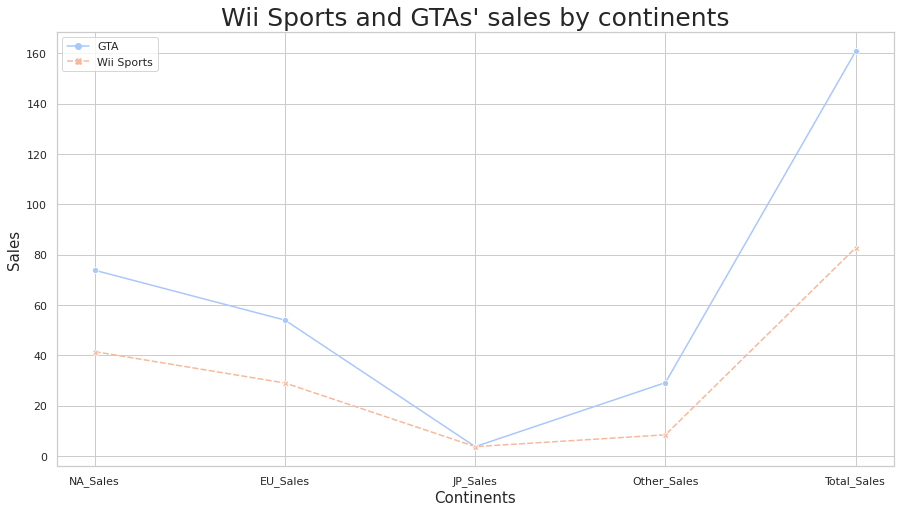

In [62]:
plt.figure(figsize=(15, 8))
plt.title("Wii Sports and GTAs' sales by continents", fontsize=25)
plt.xlabel("Continents", fontsize=15)
plt.ylabel("Sales", fontsize=15)
custom_palette = sns.color_palette("coolwarm", 2)

sns.lineplot(data=df_wii_gta, markers=True, palette= custom_palette)

**GTA 게임 시리즈들을 묶어서 Wii Sports와 비교**해보니 **일본을 제외한 모든 지역에서 판매량이 훨씬 더 많았음**을 알게 됐다.

이에 따라서 **실제로 제일 많이 팔린 게임은 GTA이며, 또한 Action 게임은 21세기부터 인기가 실제로 많았음**을 확인했다.

그런 **GTA에 대해 더 분석**해보기로 했다.

# **출고량이 높은 게임에 대한 분석 및 시각화 프로세스**

In [63]:
df_gta['Platform'].unique() #GTA를 런칭한 플랫폼 확인

array(['PSP', 'PS2', 'PS', 'PS4', 'PC', 'PS3', 'X360', 'XB', 'DS', 'GBA',
       'XOne'], dtype=object)

In [67]:
gta_plf = df_gta.groupby('Platform').sum()
gta_plf = gta_plf[['Total_Sales']]
gta_plf = gta_plf.reset_index()
gta_plf

,Platform,Total_Sales
0,DS,1.35
1,GBA,0.23
2,PC,2.10
3,PS,5.85
4,PS2,56.29
5,PS3,31.97
6,PS4,11.99
7,PSP,13.90
8,X360,27.53
9,XB,4.45


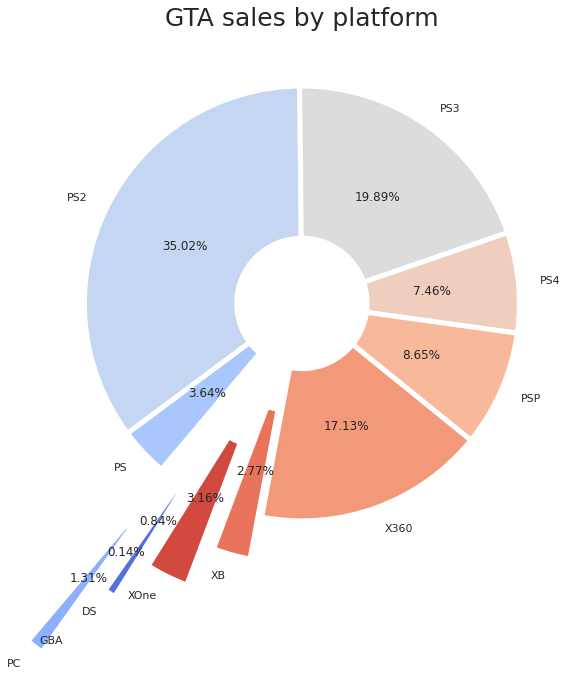

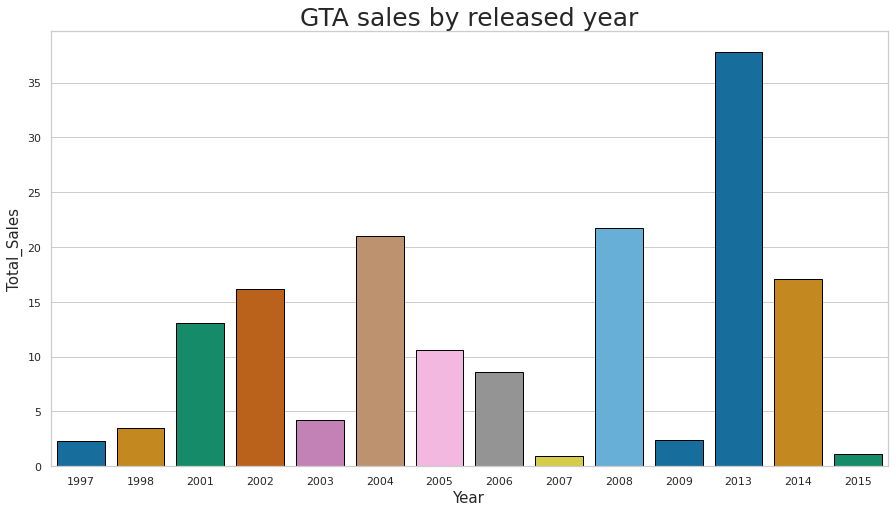

In [68]:
plt.rcParams['figure.figsize'] = [20, 10]
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}
custom_palette = sns.color_palette("coolwarm", 11)
plt.pie(gta_plf['Total_Sales'], labels = gta_plf.Platform,autopct='%.2f%%', explode = [0.6,0.8,1.0,0,0,0,0,0,0,0.2,0.4], startangle=238, counterclock=False, colors=custom_palette, wedgeprops=wedgeprops);
plt.title('GTA sales by platform' , fontsize=25)

sales_gta_year = df_gta.groupby('Year').sum()
sales_gta_year = sales_gta_year[['Total_Sales']]
sales_gta_year = sales_gta_year.reset_index()
sales_gta_year
plt.figure(figsize=(15, 8))
plt.rc('patch', edgecolor='black')
plt.xlabel("Year", fontsize = 15)
plt.ylabel("Sales", fontsize = 15)
plt.title("GTA sales by released year", fontsize = 25)
custom_palette = sns.color_palette("colorblind", 11)
sns.barplot(x='Year', y='Total_Sales',data=sales_gta_year, palette=custom_palette)

**GTA를 런칭한 11가지**의 플랫폼중 PS 시리즈, **즉 Playstation**을 통한 **판매량이 절반 이상**이었다.

또한 **연도 별로 판매량을 정리**한 그래프를 보면 **GTA의 매출이 튀는 시점이 있는데**, 이 년도는  **2001, 2004, 2008, 2013년**도로써 각각 **GTA 3, GTA: San andreas, GTA 4, GTA 5가 런칭한 년도**와 일치한다.

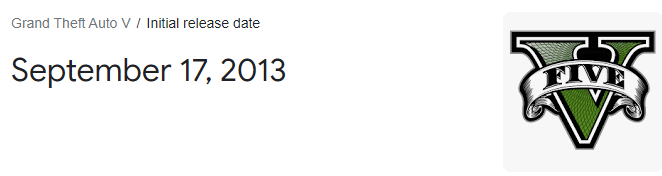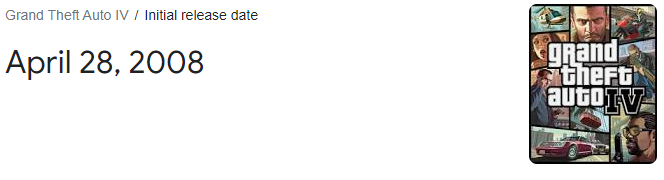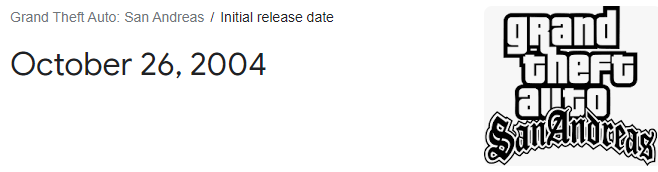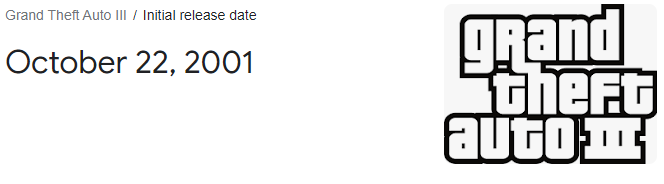

**GTA 관련해서만 Playstation이 판매량을 많이 기록했는지** 아니면 **다른 게임들까지 통틀어서 Playstaion의 판매량이 높은건지** 확인해보자.

# **연도별 플랫폼의 트렌드 확인해보자**

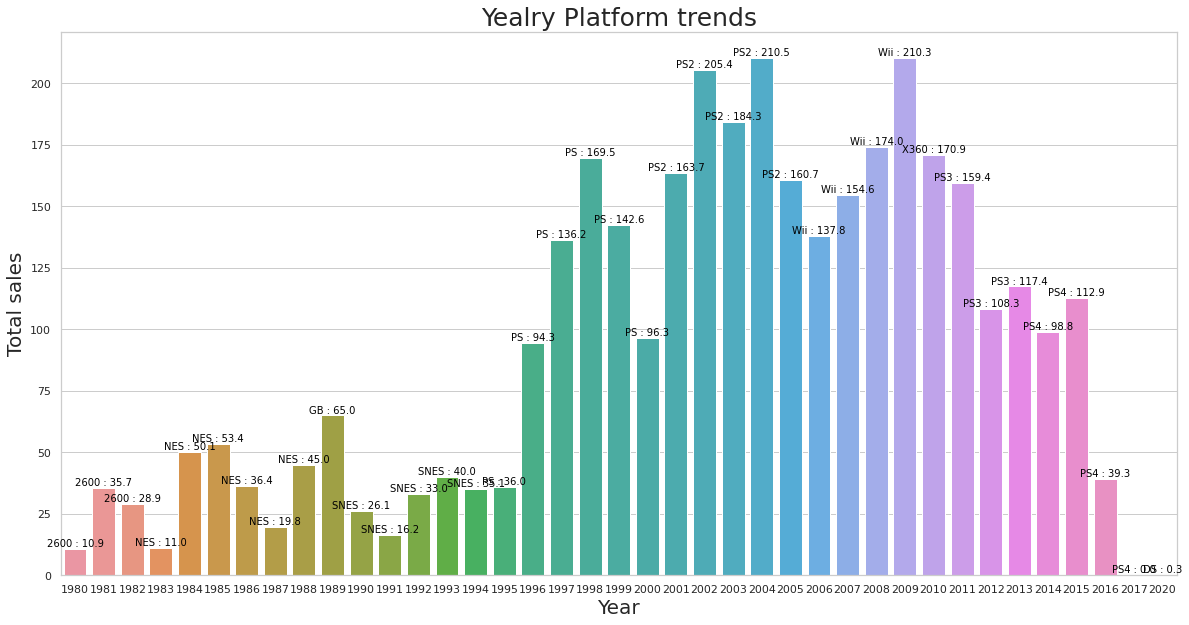

In [69]:
platform_yearly_index = df.groupby(by=['Year', 'Platform'])['Total_Sales'].sum()
platform_yearly_index = platform_yearly_index.reset_index()
platform_yearly = platform_yearly_index.groupby(by=['Year'])['Total_Sales'].transform(max) == platform_yearly_index['Total_Sales']
platform_yearly_top = platform_yearly_index[platform_yearly].reset_index()

platform = platform_yearly_top['Platform']

sns.set(style='whitegrid')
plt.figure(figsize=(20, 10))
trends = sns.barplot(x='Year', y='Total_Sales', data=platform_yearly_top)

index = 0
for value in platform_yearly_top['Total_Sales']:
    trends.text(index, value + 1, str(platform[index] + ' : ' +str(round(value, 1))), color='black', size=10, ha="center")
    index += 1

plt.title("Yealry Platform trends", fontsize=25)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Total sales", fontsize=20)

plt.show()

확인 결과 21세기 이후, **2006년부터 2009년 Wii**에게 판매량이 뒤쳐졌던 해를 제외하고는 **Playstaion이 가장 많은 판매량**을 기록했음을 알 수 있다.

**Playstation**은 GTA에 한정되어 판매량이 높았던 것이 아니라, 다른 게임들을 통틀어서 전체적인 판매량을 고려했을 때에도 **시장에서 가장 선호되는 플랫폼**임을 발견했다.

# **그렇다면 다음 분기에 어떤 게임을 설계해야 할까?**

**최근 10년 내의 게임시장의 트렌드를 고려**했을 때 **Playstaion을 플랫폼 기반**으로 **Action 장르의 시리즈 물**이나, **Shooter 장르의 시리즈 물**을 설계하는 것이  가장 이상적일 것 같다는 결론이 나왔다.

그렇다면 마지막으로 **나의 결론**과 **게임 시장이 실제로 가장 기대하는 내년 게임들의 종류**를 **비교**해보자.

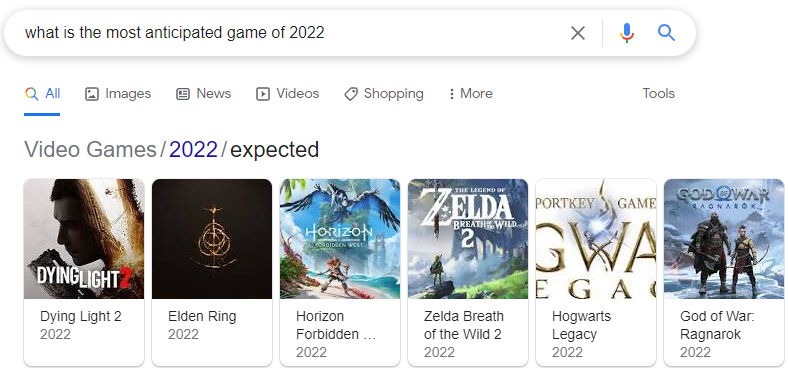

In [71]:
game2022 = pd.DataFrame({'Name':["Dying Light 2","Elden Ring", "Horizon Forbidden West", "Zelda Breath of the Wild 2", "Hogwarts Legacy", "God of War Ragnarök"],
                         'Platform':["Playstation","Playstation","Playstation","Nintendo Switch","Playstation","Playstation"],
                         'Year':[2022,2022,2022,2022,2022,2022],
                         'Genre':["Action","Action","Action","Action","Action","Action"],
                         'Is genre Series':["Yes","No","Yes","Yes","Yes","Yes"]})
game2022

,Name,Platform,Year,Genre,Is genre Series
0,Dying Light 2,Playstation,2022,Action,Yes
1,Elden Ring,Playstation,2022,Action,No
2,Horizon Forbidden West,Playstation,2022,Action,Yes
3,Zelda Breath of the Wild 2,Nintendo Switch,2022,Action,Yes
4,Hogwarts Legacy,Playstation,2022,Action,Yes
5,God of War Ragnarök,Playstation,2022,Action,Yes


**플랫폼이 Playstation**인 5개의 게임중 **Horizon Forbidden West, God of War Ragnarök**는 다른 플랫폼에서는 게임을 출시하지 않고 **Playstation에서만 단독 출시할 예정**이다.

또한 **6개의 게임 모두 Action 장르**이며, 그 중 **5개의 게임은 시리즈물**이다.

# **감사합니다!**